# Applied Machine Learning

## Assignment3 - ShunFai Lee

### Question1:

#### Hyperparameter Tuning and evaluation for decision tree, random forest, and neural network

Using  fake news dataset (https://www.kaggle.com/clmentbisaillon/fake-and-real-news-dataset)

In [71]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, recall_score
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import tree, neural_network
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline

In [72]:
#load true/fake news data set
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")
df_true['class']=0
df_fake['class']=1
print(f'true news: total no.:{len(df_true)}, cols: {df_true.columns}')
print(f'fake news: total no.:{len(df_fake)}, cols: {df_fake.columns}')

df_news = pd.concat([df_true,df_fake])
print(f'all news: total no.:{len(df_news)}, cols: {df_news.columns}')

X_train, X_test, Y_train, Y_test = train_test_split(df_news['title'], df_news['class'], test_size=0.1, random_state=1, stratify=df_news['class'])

true news: total no.:21417, cols: Index(['title', 'text', 'subject', 'date', 'class'], dtype='str')
fake news: total no.:23481, cols: Index(['title', 'text', 'subject', 'date', 'class'], dtype='str')
all news: total no.:44898, cols: Index(['title', 'text', 'subject', 'date', 'class'], dtype='str')


In [73]:
#run a beseline logisticregression
testsize = 0.1
print(f"run baseline using logistic regression, with testsize:{testsize}")

pipe_lr = make_pipeline(TfidfVectorizer(stop_words='english', max_features=40),LogisticRegression(max_iter= 1000))
pipe_lr.fit(X_train, Y_train)
score = pipe_lr.score(X_test,Y_test)
print(f"baseline score: {score}")

#stratified version
scores = []
kfold = StratifiedKFold(n_splits=10).split(X_train, Y_train)
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train.iloc[train], Y_train.iloc[train])
    score_k = pipe_lr.score(X_train.iloc[test], Y_train.iloc[test])
    scores.append(score_k)
    print(f'Fold: {k+1:02d}, 'f'Class distr.: {np.bincount(Y_train.iloc[train])}, 'f'Acc.: {score_k:.5f}')
mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f'\nCV accuracy: {mean_acc:.5f} +/- {std_acc:.5f}')

#cross-validation
cross_score = cross_val_score(pipe_lr,X_train,Y_train,cv=10,n_jobs=-1)
cross_score

run baseline using logistic regression, with testsize:0.1
baseline score: 0.8080178173719377
Fold: 01, Class distr.: [17348 19019], Acc.: 0.80401
Fold: 02, Class distr.: [17348 19019], Acc.: 0.80871
Fold: 03, Class distr.: [17348 19019], Acc.: 0.80327
Fold: 04, Class distr.: [17347 19020], Acc.: 0.80921
Fold: 05, Class distr.: [17347 19020], Acc.: 0.79659
Fold: 06, Class distr.: [17347 19020], Acc.: 0.78990
Fold: 07, Class distr.: [17347 19020], Acc.: 0.81218
Fold: 08, Class distr.: [17347 19020], Acc.: 0.79980
Fold: 09, Class distr.: [17348 19020], Acc.: 0.80520
Fold: 10, Class distr.: [17348 19020], Acc.: 0.80545

CV accuracy: 0.80343 +/- 0.00623


array([0.80400891, 0.80871072, 0.80326652, 0.80920564, 0.796585  ,
       0.78990349, 0.8121752 , 0.79980203, 0.80519802, 0.80544554])

In [74]:
# Define some common functions
def tpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

def precision_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (fp + tp)

scoring_metrics = {
    'accuracy': 'accuracy',
    "tpr": make_scorer(tpr_score),
    "fpr": make_scorer(fpr_score),
    "precision": make_scorer(precision_score)
}

### Question1: Decision Tree Plot

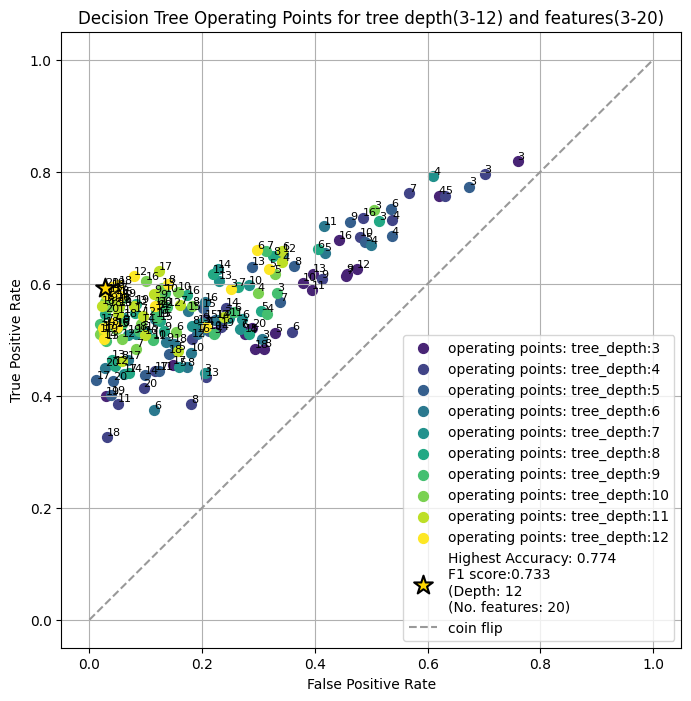

In [75]:
#define parameters for the model
Tfidf_Max_f = 100
tree_depth = np.arange(3,13,1)
tree_feature = np.arange(3,21,1)
pipe_all= Pipeline([('Tfidf',TfidfVectorizer(stop_words='english', max_features=Tfidf_Max_f)),('model',tree.DecisionTreeClassifier())])
param_grid = [{'model':[tree.DecisionTreeClassifier()],'model__max_depth': tree_depth,'model__max_features': tree_feature}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_all,param_grid=param_grid,scoring=scoring_metrics,refit='accuracy',cv=cv,n_jobs=-1)
gs.fit(X_train,Y_train)

#extract results
TPR = gs.cv_results_['mean_test_tpr']
FPR = gs.cv_results_['mean_test_fpr']
ACC = gs.cv_results_['mean_test_accuracy']
PRE = gs.cv_results_['mean_test_precision']
features = gs.cv_results_['param_model__max_features'].data
depth = gs.cv_results_['param_model__max_depth'].data

# Find the coordinates and data for the best model
best_idx = np.argmax(ACC)
best_fpr = FPR[best_idx]
best_tpr = TPR[best_idx]
best_acc = ACC[best_idx]
best_feature = features[best_idx]
best_depth = depth[best_idx]
best_pre = PRE[best_idx]
best_F1 = 2*best_pre*best_tpr/(best_pre+best_tpr)

#plot the graph
cmap = plt.cm.viridis
color_map = np.linspace(0.1,1,len(tree_depth))
fig, ax = plt.subplots(1, figsize=(8, 8))
for i in range(len(tree_depth)):
    indice = np.where(depth == tree_depth[i])[0]
    TPR_i = TPR[indice]
    FPR_i = FPR[indice]
    fpr = [0.]+list(FPR_i)+[1.]; tpr = [0.]+list(TPR_i)+[1.]
    ax.scatter(FPR_i, TPR_i, 50, color=cmap(color_map[i]), marker='o', label=f'operating points: tree_depth:{tree_depth[i]}')
    for j in range(len(indice)):
        ax.text(
            FPR_i[j],
            TPR_i[j],
            str(features[indice][j]),
            fontsize=8,
            ha='left',
            va='bottom'
        )

#annotate the best operation point
ax.scatter(best_fpr, best_tpr, color='gold', marker='*', 
    s=200, edgecolor='black', linewidth=1.5,
    label=f'Highest Accuracy: {best_acc:.3f}\nF1 score:{best_F1:.3f}\n(Depth: {best_depth}\n(No. features: {best_feature})', 
    zorder=4
)

ax.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='coin flip')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='Decision Tree Operating Points for tree depth(3-12) and features(3-20)')
ax.grid(True)
plt.legend(loc='lower right')
plt.show()

ROC plot of Decision Tree with maximum tree depth from between 3 to 12, and maximum tree features between 3 to 20<br>
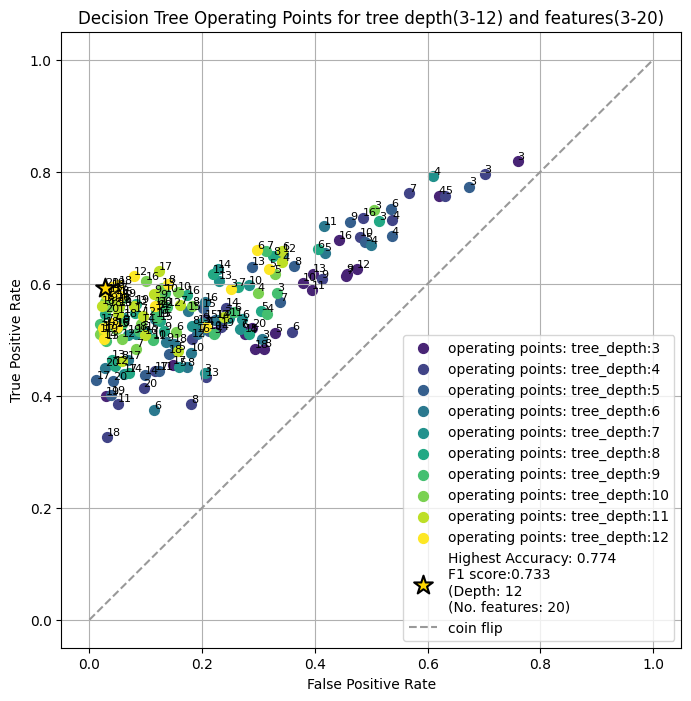


### Question1: Random Forest Plot

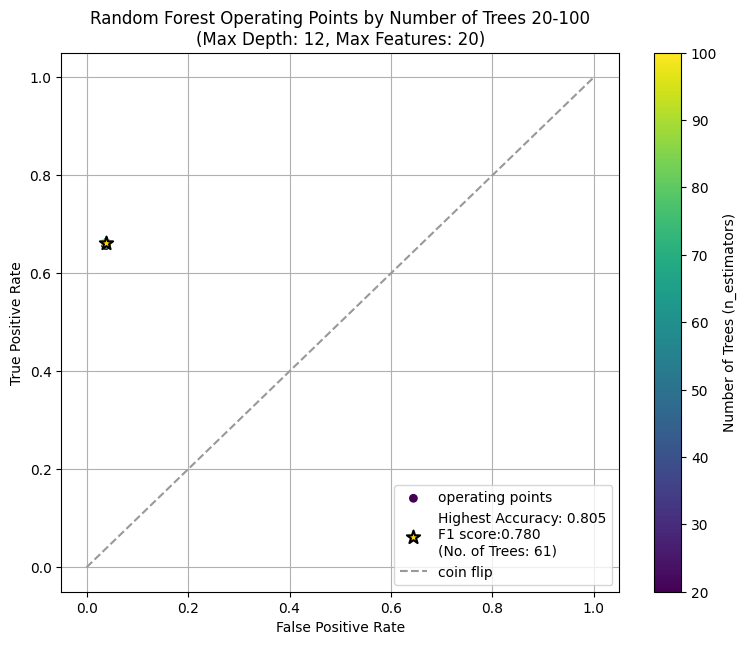

In [76]:
#define parameters for the model
ntree = np.arange(20,101,1)
Tfidf_Max_f = 100
pipe_all= Pipeline([('Tfidf',TfidfVectorizer(stop_words='english', max_features=Tfidf_Max_f)),('model',RandomForestClassifier(max_depth=12,max_features=20,random_state=42))])
param_grid = [{'model__n_estimators': ntree}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_all,param_grid=param_grid,scoring=scoring_metrics,refit='accuracy',cv=cv,n_jobs=-1)
gs.fit(X_train,Y_train)

#extract results
TPR = gs.cv_results_['mean_test_tpr']
FPR = gs.cv_results_['mean_test_fpr']
ACC = gs.cv_results_['mean_test_accuracy']
trees = gs.cv_results_['param_model__n_estimators'].data
PRE = gs.cv_results_['mean_test_precision']

# Find the coordinates and data for the best model
best_idx = np.argmax(ACC)
best_fpr = FPR[best_idx]
best_tpr = TPR[best_idx]
best_acc = ACC[best_idx]
best_tree = trees[best_idx]
best_pre = PRE[best_idx]
best_F1 = 2*best_pre*best_tpr/(best_pre+best_tpr)

#plot the graph
fig, ax = plt.subplots(1, figsize=(9, 7))
fpr = [0.]+list(FPR)+[1.]; tpr = [0.]+list(TPR)+[1.]
sc = ax.scatter(FPR, TPR, c=trees, cmap='viridis', s=40, edgecolor='none',label=f'operating points')

#annotate the best operation point
ax.scatter(best_fpr, best_tpr, color='gold', marker='*', 
    s=100, edgecolor='black', linewidth=1.5,
    label=f'Highest Accuracy: {best_acc:.3f}\nF1 score:{best_F1:.3f}\n(No. of Trees: {best_tree})', 
    zorder=4
)

cbar = plt.colorbar(sc)
cbar.set_label('Number of Trees (n_estimators)')

ax.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='coin flip')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'Random Forest Operating Points by Number of Trees {ntree[0]}-{ntree[-1]}\n(Max Depth: 12, Max Features: 20)')
ax.grid(True)
plt.legend(loc='lower right')
plt.show()

ROC plot of Random Forest with maximum tree depth set at 12 and maximum features set at 20, and varying the number of trees between 20 to 100<br>
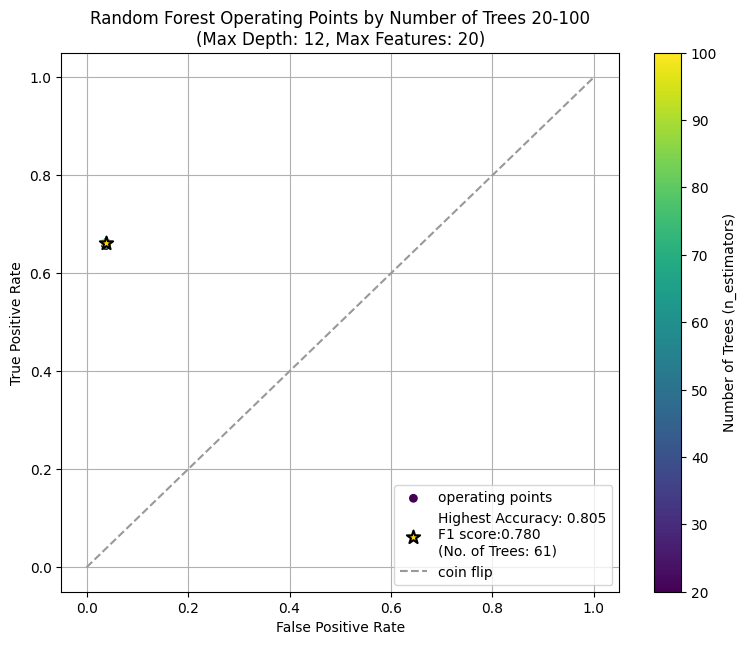

### Question1: neural network plot

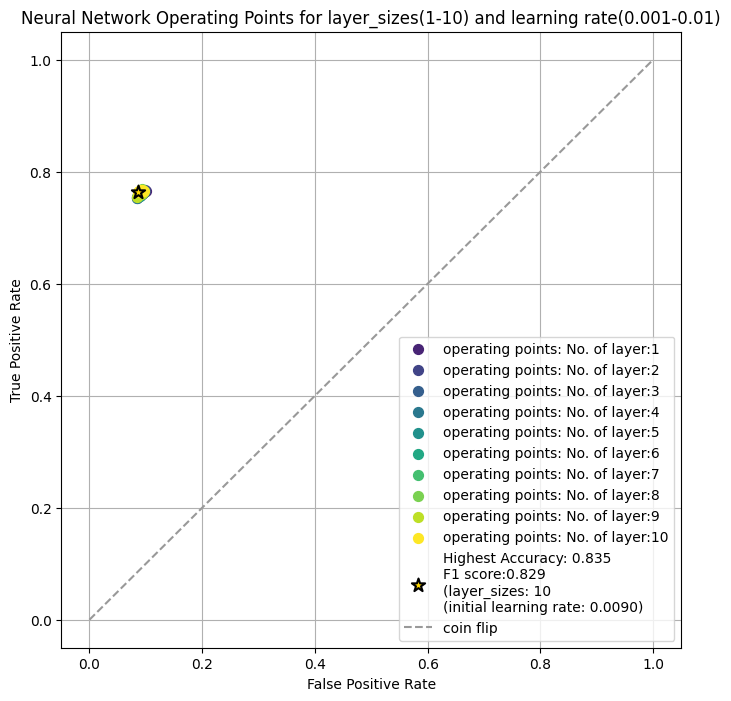

In [77]:
#define parameters for the model
Tfidf_Max_f = 100
n_layer = np.arange(1,11,1)
n_learningrate = np.linspace(0.001,0.01,10)
pipe_all= Pipeline([('Tfidf',TfidfVectorizer(stop_words='english', max_features=Tfidf_Max_f)),('model',neural_network.MLPClassifier(max_iter=500,early_stopping=True,validation_fraction=0.1,n_iter_no_change=10,tol=1e-4,random_state=42))])
param_grid = [{'model__hidden_layer_sizes': [(n,) for n in n_layer],'model__learning_rate_init': n_learningrate}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_all,param_grid=param_grid,scoring=scoring_metrics,refit='accuracy',cv=cv,n_jobs=-1)
gs.fit(X_train,Y_train)

#extract results
TPR = gs.cv_results_['mean_test_tpr']
FPR = gs.cv_results_['mean_test_fpr']
ACC = gs.cv_results_['mean_test_accuracy']
PRE = gs.cv_results_['mean_test_precision']

# Extract the first element of the tuple from layer parameter
layers = np.array([x[0] for x in gs.cv_results_['param_model__hidden_layer_sizes'].data])
ini_learning_rates = gs.cv_results_['param_model__learning_rate_init'].data

# Find the coordinates and data for the best model
best_idx = np.argmax(ACC)
best_fpr = FPR[best_idx]
best_tpr = TPR[best_idx]
best_acc = ACC[best_idx]
best_layer = layers[best_idx]
best_learning_rate = ini_learning_rates[best_idx]
best_pre = PRE[best_idx]
best_F1 = 2*best_pre*best_tpr/(best_pre+best_tpr)

#plot the graph
cmap = plt.cm.viridis
color_map = np.linspace(0.1,1,len(n_layer))
fig, ax = plt.subplots(1, figsize=(8, 8))
for i in range(len(n_layer)):
    indice = np.where(layers == n_layer[i])[0]
    TPR_i = TPR[indice]
    FPR_i = FPR[indice]
    fpr = [0.]+list(FPR_i)+[1.]; tpr = [0.]+list(TPR_i)+[1.]
    ax.scatter(FPR_i, TPR_i, 50, color=cmap(color_map[i]), marker='o', label=f'operating points: No. of layer:{n_layer[i]}')

#annotate the best operation point
ax.scatter(best_fpr, best_tpr, color='gold', marker='*', 
    s=100, edgecolor='black', linewidth=1.5,
    label=f'Highest Accuracy: {best_acc:.3f}\nF1 score:{best_F1:.3f}\n(layer_sizes: {best_layer}\n(initial learning rate: {best_learning_rate:.4f})', 
    zorder=4
)

ax.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='coin flip')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'Neural Network Operating Points for layer_sizes({n_layer[0]}-{n_layer[-1]}) and learning rate({n_learningrate[0]}-{n_learningrate[-1]})')
ax.grid(True)
plt.legend(loc='lower right')
plt.show()

ROC plot of Neural Network with No. of layer from 1 to 10 and 10 different learning rate from between 0.001 to 0.01<br>
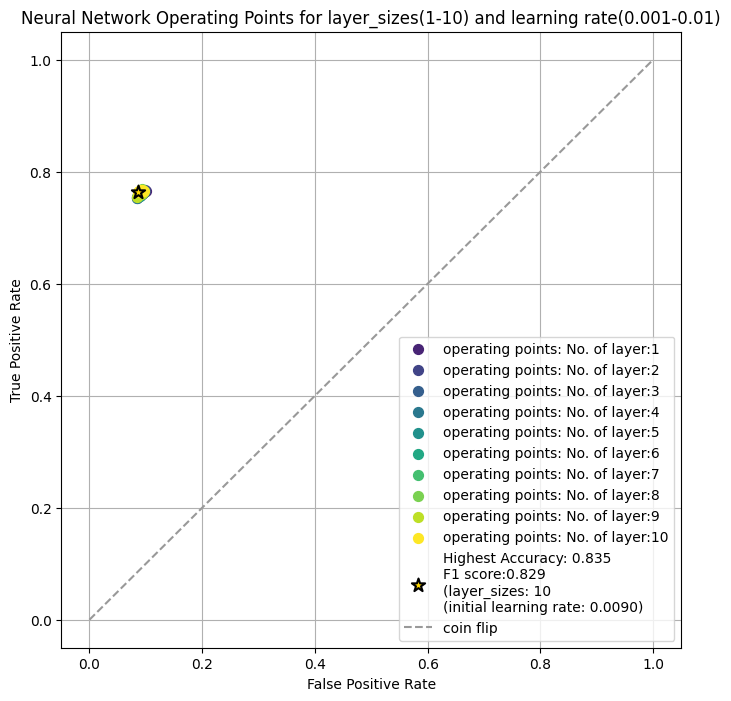

### Question2:

As according to lectures and office hours tutorial, I would expect to see a trend of Pd increase with Pf, but the tendency would looks like a concave curve towards higher TPR rate, i.e. bend towards the top left corner.<br>
However, both random forest and neural network shows that the different operating points yield very close results. Only the plot of decision tree is shows the expected behavior of Pd-Pf, 

### Question3:

I would choose the neural network. It is because neural network gives the overall best result among all three classifier, with the best TPR at a similar FPR, and the best accuracy and F1 score. And as for the parameter, I would set layer size = 1 and initial learning rate = 0.009. The reason for layer size = 1 is that the number of layers almost has no influence on the performance of neural network.


### Question4: Retrain neural network with text coloumn from data set


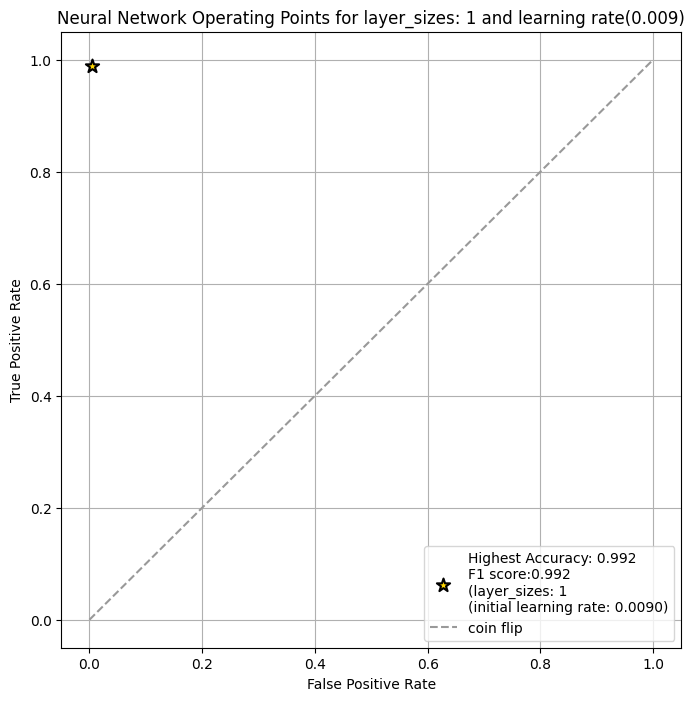

score on test set: 0.9913140311804008


In [79]:
#read data set
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")
df_true['class']=0
df_fake['class']=1
df_news = pd.concat([df_true,df_fake])

#Combine title and text into a single column and create the new dataset
df_news['full_text'] = df_news['title'] + " " + df_news['text']
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(df_news['full_text'], df_news['class'], test_size=0.1, random_state=1, stratify=df_news['class'])

#define parameters for the model
Tfidf_Max_f = 100
pipe_all= Pipeline([('Tfidf',TfidfVectorizer(stop_words='english', max_features=Tfidf_Max_f)),('model',neural_network.MLPClassifier(max_iter=500,early_stopping=True,validation_fraction=0.1,n_iter_no_change=10,tol=1e-4,random_state=42))])
#add only 1 layer and learning rate
param_grid = [{'model__hidden_layer_sizes': [(1,)],'model__learning_rate_init': [0.009]}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_all,param_grid=param_grid,scoring=scoring_metrics,refit='accuracy',cv=cv,n_jobs=-1)
gs.fit(X_train2,Y_train2)

#extract results
TPR = gs.cv_results_['mean_test_tpr']
FPR = gs.cv_results_['mean_test_fpr']
ACC = gs.cv_results_['mean_test_accuracy']
layers = np.array([x[0] for x in gs.cv_results_['param_model__hidden_layer_sizes'].data])
ini_learning_rates = gs.cv_results_['param_model__learning_rate_init'].data
PRE = gs.cv_results_['mean_test_precision']

# Find the coordinates and data for the best model
best_idx = np.argmax(ACC)
best_fpr = FPR[best_idx]
best_tpr = TPR[best_idx]
best_acc = ACC[best_idx]
best_layer = layers[best_idx]
best_learning_rate = ini_learning_rates[best_idx]
best_pre = PRE[best_idx]
best_F1 = 2*best_pre*best_tpr/(best_pre+best_tpr)

#plot the graph
fig, ax = plt.subplots(1, figsize=(8, 8))

#annotate the best operation point
ax.scatter(best_fpr, best_tpr, color='gold', marker='*', 
    s=100, edgecolor='black', linewidth=1.5,
    label=f'Highest Accuracy: {best_acc:.3f}\nF1 score:{best_F1:.3f}\n(layer_sizes: {best_layer}\n(initial learning rate: {best_learning_rate:.4f})', 
    zorder=4
)

ax.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='coin flip')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'Neural Network Operating Points for layer_sizes: {layers[0]} and learning rate({ini_learning_rates[0]})')
ax.grid(True)
plt.legend(loc='lower right')
plt.show()

print(f'score on test set: {gs.score(X_test2,Y_test2)}')

### Question4:
Result of re-trained model:<br>
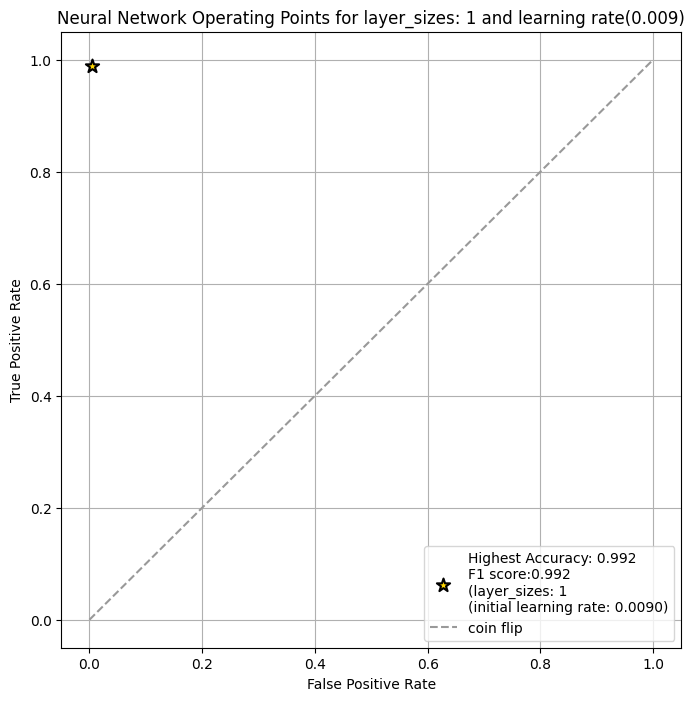 <br>
After adding "text" column, the retrained neural network model a has a significantly better, almost perfect performance, that accuracy is at 99.2% and F1 score at 0.992. TPR is close to 1 and FPR is close to 0.
The retrained model also give a 99.13% accuracy on the test set, which is very well.<br>
I think the major reason for this performance jump is due to the immense amount of extra information contained in 'text', as compared with just the 'title' that contains only a few words.